## COVID Drivers: Modeling

This notebook models AGGRESSIVE_DRIVING ~ POST_COVID using logistic regression.

### Table of Contents
* [Read the Data](#read)</BR>
* [Preprocessing](#prep)</BR>
* [Logistic Regression with Cross Validation](#lgr-cv)</BR>
* [Logistic Regression with Statsmodels](#sm)</BR>
* [Preprocessing for Robustness Testing](#prep-rob)</BR>
* [Robustness Testing with Statsmodels](#sm-rob)

Import packages

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

import xgboost as xgb
from functools import reduce
#import prince

import statsmodels.api as sm
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, PolynomialFeatures
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, classification_report, RocCurveDisplay

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path_in = '/content/drive/MyDrive/Colab Notebooks/Case Studies in Data Science/data/ready/ready_data_final.csv'

In [ ]:
path_out = 'metrics_06_prim_modl_lgr.csv'

### <a id='read'>Read the data</a>

In [ ]:
df_init = pd.read_csv(path_in, low_memory=False)

In [ ]:
df_init['CRASH_DATE'] = pd.to_datetime(df_init['CRASH_DATE'])

In [ ]:
df = df_init.drop(columns=['CRN']).copy()

In [ ]:
model_metrics = []

In [ ]:
df.columns.tolist()

['CRASH_DATE',
 'URBAN_RURAL',
 'URBAN_RURALx',
 'POST_COVID',
 'AGGRESSIVE_DRIVING',
 'NHTSA_AGG_DRIVING',
 'NO_CLEARANCE',
 'RUNNING_RED_LT',
 'RUNNING_STOP_SIGN',
 'SPEEDING',
 'SPEEDING_RELATED',
 'TAILGATING',
 'CELL_PHONE',
 'DISTRACTED']

### <a id='prep'>Preprocessing</a>

In [ ]:
X = df.loc[:,['POST_COVID']].copy()

In [ ]:
y = df['AGGRESSIVE_DRIVING']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### <a id='lgr-cv1'>Logistic Regression with Cross Validation</a>

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
lgr_pipeline = Pipeline(steps=[
    ('logistic_regression', LogisticRegressionCV(random_state=42, cv=skf, max_iter=5000))
])

In [ ]:
lgr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('logistic_regression',
                 LogisticRegressionCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                                      max_iter=5000, random_state=42))])

In [ ]:
y_pred = lgr_pipeline.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 55.98%


In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)

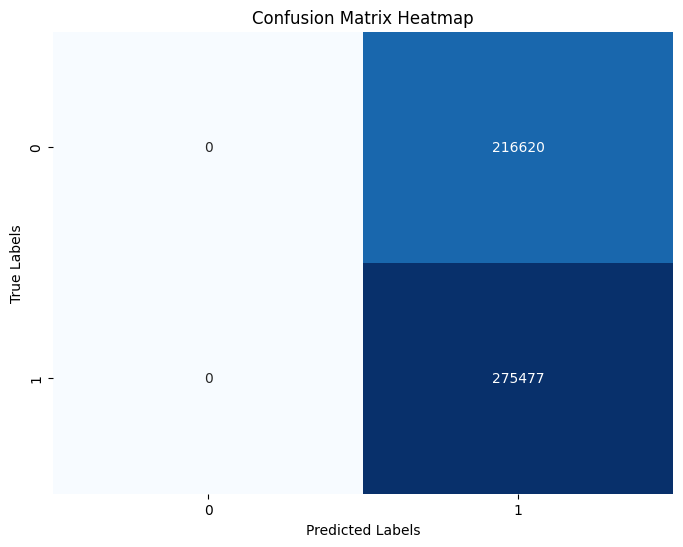

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [ ]:
# Extract the trained LogisticRegressionCV model
model = lgr_pipeline.named_steps['logistic_regression']

In [ ]:
# Get Feature Names from Preprocessor - ColumnTransformer
feature_names = lgr_pipeline.named_steps['logistic_regression'].feature_names_in_

In [ ]:
# Get Coefficients (feature importance)
# model.coef_ shape is (1, n_features) for binary, or (n_classes, n_features)
# Using absolute value to get magnitude
importances = np.abs(model.coef_[0])

In [ ]:
# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

In [ ]:
print(feature_importance_df)

      Feature  Importance
0  POST_COVID    0.029967


Feature: 0, Score: 0.02997


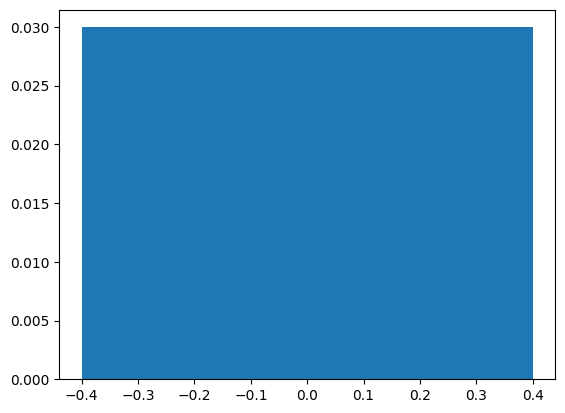

In [ ]:
for i,v in enumerate(importances):
	print('Feature: %0d, Score: %.5f' % (i,v))
# plot feature importance
plt.bar([x for x in range(len(importances))], importances)
plt.show()

In [ ]:
# Predicted probabilities for the class 1
y_pred_proba = lgr_pipeline.predict_proba(X_test)[:, 1]

In [ ]:
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {auc_score:.4f}")

ROC AUC Score: 0.5030


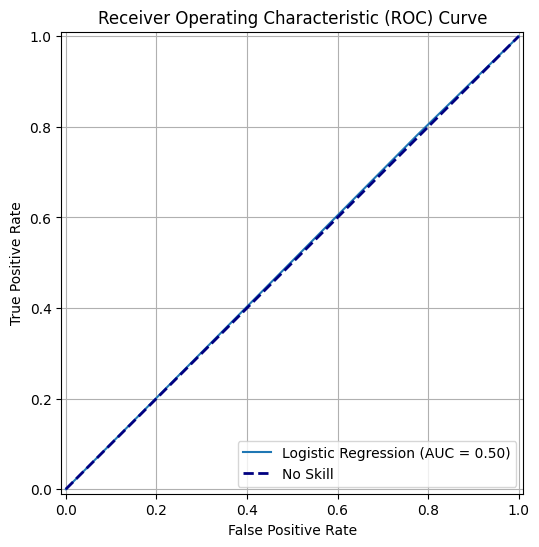

In [ ]:
# Plot the ROC curve
# Using RocCurveDisplay.from_estimator is the recommended method in modern scikit-learn
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(lgr_pipeline, X_test, y_test, ax=ax, name="Logistic Regression")

# Plot the "no skill" or chance level baseline
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='No Skill')

# Customize the plot
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Receiver Operating Characteristic (ROC) Curve")
ax.legend(loc="lower right")
ax.grid(True)
plt.show()

In [ ]:
# Precision: tp / (tp + fp)
precision = precision_score(y_test, y_pred)

In [ ]:
# Recall: tp / (tp + fn)
recall = recall_score(y_test, y_pred)

In [ ]:
# F1-score: harmonic mean of precision and recall
f1 = f1_score(y_test, y_pred)

In [ ]:
# ROC AUC: Area Under the Receiver Operating Characteristic Curve
roc_auc = roc_auc_score(y_test, y_pred_proba)

In [ ]:
measure_titles = ['Accuracy','Precision','Recall','F1 Score','ROC AUC']
measure_value = [accuracy,precision,recall,f1,roc_auc]
model = 'LogisticRegressionCV'

In [ ]:
aggdrv_lgrcv = pd.DataFrame({'Measure':measure_titles,
                            model:measure_value})

In [ ]:
aggdrv_lgrcv['LogisticRegressionCV'] = [round(x, 4) for x in aggdrv_lgrcv['LogisticRegressionCV']]

In [ ]:
aggdrv_lgrcv

,Measure,LogisticRegressionCV
0,Accuracy,0.5598
1,Precision,0.5598
2,Recall,1.0000
3,F1 Score,0.7178
4,ROC AUC,0.5030


In [ ]:
# Comprehensive classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00    216620
           1       0.56      1.00      0.72    275477

    accuracy                           0.56    492097
   macro avg       0.28      0.50      0.36    492097
weighted avg       0.31      0.56      0.40    492097



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### <a id='sm'>Logistic Regression with Statsmodels</a>

In [ ]:
X_train = sm.add_constant(X_train)

In [ ]:
logit_model = sm.Logit(y_train, X_train)

In [ ]:
result = logit_model.fit()

Optimization terminated successfully.
         Current function value: 0.685952
         Iterations 4


In [ ]:
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:     AGGRESSIVE_DRIVING   No. Observations:              1968387
Model:                          Logit   Df Residuals:                  1968385
Method:                           MLE   Df Model:                            1
Date:                Thu, 16 Apr 2026   Pseudo R-squ.:               3.662e-05
Time:                        00:55:58   Log-Likelihood:            -1.3502e+06
converged:                       True   LL-Null:                   -1.3503e+06
Covariance Type:            nonrobust   LLR p-value:                 2.678e-23
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2479      0.002    152.465      0.000       0.245       0.251
POST_COVID    -0.0345      0.003     -9.947      0.000      -0.041      -0.028


### <a id='prep-rob'>Preprocessing for Robustness Testing</a>

In [ ]:
#df1 = df.loc[df['URBAN_RURALx']=='Urbanized'].copy()
df1 = df.loc[(df['CRASH_DATE'] >= pd.to_datetime('2019-03-01', format='%Y-%m-%d')) & (df['CRASH_DATE'] < pd.to_datetime('2021-03-01', format='%Y-%m-%d'))].copy()

In [ ]:
#df2 = df.loc[df['URBAN_RURALx']=='Rural'].copy()
df2 = df.loc[df['CRASH_DATE'] >= pd.to_datetime('2015-03-01', format='%Y-%m-%d')].copy()

In [ ]:
#df.shape[0] == df1.shape[0] + df2.shape[0]

In [ ]:
X1 = df1.loc[:,['POST_COVID']].copy()

In [ ]:
X2 = df2.loc[:,['POST_COVID']].copy()

In [ ]:
y1 = df1['AGGRESSIVE_DRIVING']
y2 = df2['AGGRESSIVE_DRIVING']

In [ ]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, stratify=y1, random_state=42)

In [ ]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, stratify=y2, random_state=42)

In [ ]:
add_constant_func = FunctionTransformer(sm.add_constant)

### <a id='sm-rob'>Robustness Testing with Statsmodels</a>

In [ ]:
X1_train = sm.add_constant(X1_train)

In [ ]:
#X_train_sm = sm.add_constant(X_train_final)
model = sm.Logit(y1_train.values, X1_train)

In [ ]:
result1 = model.fit()

Optimization terminated successfully.
         Current function value: 0.688087
         Iterations 4


In [ ]:
print(result1.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:               180806
Model:                          Logit   Df Residuals:                   180804
Method:                           MLE   Df Model:                            1
Date:                Fri, 17 Apr 2026   Pseudo R-squ.:               0.0001048
Time:                        01:09:11   Log-Likelihood:            -1.2441e+05
converged:                       True   LL-Null:                   -1.2442e+05
Covariance Type:            nonrobust   LLR p-value:                 3.276e-07
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2224      0.006     34.657      0.000       0.210       0.235
POST_COVID    -0.0485      0.009     -5.107      0.000      -0.067      -0.030


In [ ]:
importances1 = result1.params.abs().sort_values(ascending=False)
print(importances1.sort_values(ascending=False))

const         0.222393
POST_COVID    0.048464
dtype: float64


In [ ]:
X2_train = sm.add_constant(X2_train)

In [ ]:
#X_train_sm = sm.add_constant(X_train_final)
model = sm.Logit(y2_train.values, X2_train)

In [ ]:
result2 = model.fit()

Optimization terminated successfully.
         Current function value: 0.686757
         Iterations 4


In [ ]:
print(result2.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:               940504
Model:                          Logit   Df Residuals:                   940502
Method:                           MLE   Df Model:                            1
Date:                Fri, 17 Apr 2026   Pseudo R-squ.:               2.905e-05
Time:                        01:09:16   Log-Likelihood:            -6.4590e+05
converged:                       True   LL-Null:                   -6.4592e+05
Covariance Type:            nonrobust   LLR p-value:                 9.021e-10
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2382      0.003     84.271      0.000       0.233       0.244
POST_COVID    -0.0255      0.004     -6.126      0.000      -0.034      -0.017


In [ ]:
importances2 = result2.params.abs().sort_values(ascending=False)
print(importances2.sort_values(ascending=False))

const         0.238224
POST_COVID    0.025508
dtype: float64


In [ ]:
print(importances1.sort_values(ascending=False))

const         0.222393
POST_COVID    0.048464
dtype: float64
